# $(SASA) Kmeans - Models$

In [1]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pickle
import numpy as np
import pandas as pd

from pmbrl.model2 import Base_Line_Simple_Model
# from pmbrl.model2 import Model, Regularized_Reference_Loss
from pmbrl.data import Experiment_Data, get_data_expanded

In [2]:
data = Experiment_Data()

data.load(path='../training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
1605,27,65,"(0.1785778102029531, 1.438381745613701)","(0.065, 0.569, -0.114, -0.503)",1,1.0,"(0.076, 0.756, -0.124, -0.623)",0.0,1.0,"(0.092, 0.57, -0.136, -0.53)"
1730,4,69,"(0.1433033517266329, 1.8075969481187537)","(0.001, 0.002, 0.042, 0.037)",0,1.0,"(0.001, -0.184, 0.043, 0.125)",0.0,1.0,"(-0.003, -0.37, 0.045, 0.212)"
1744,18,69,"(0.1433033517266329, 1.8075969481187537)","(-0.055, -0.001, 0.086, 0.115)",1,1.0,"(-0.055, 0.184, 0.089, 0.04)",1.0,1.0,"(-0.051, 0.369, 0.089, -0.035)"
1588,10,65,"(0.1785778102029531, 1.438381745613701)","(-0.026, 0.376, -0.03, -0.258)",1,1.0,"(-0.019, 0.563, -0.035, -0.37)",0.0,1.0,"(-0.007, 0.376, -0.042, -0.266)"
915,0,38,"(0.4545373771214862, 0.5810082803318615)","(-0.001, -0.025, 0.022, 0.013)",1,1.0,"(-0.002, 0.172, 0.022, -0.318)",0.0,1.0,"(0.002, -0.026, 0.016, 0.03)"
...,...,...,...,...,...,...,...,...,...,...
2445,15,95,"(0.0558866920316977, 1.0277254711695958)","(-0.145, -1.651, 0.082, 1.222)",0,1.0,"(-0.178, -1.839, 0.107, 1.372)",0.0,1.0,"(-0.215, -2.028, 0.134, 1.525)"
187,71,6,"(0.2451557536988955, 1.3793967951445396)","(-0.262, -0.562, -0.038, 0.001)",1,1.0,"(-0.273, -0.374, -0.038, -0.122)",0.0,1.0,"(-0.28, -0.561, -0.04, -0.009)"
2410,33,94,"(0.4377652476268179, 0.9729568415243506)","(0.04, 0.958, 0.07, -0.491)",0,1.0,"(0.06, 0.767, 0.06, -0.277)",1.0,1.0,"(0.075, 0.957, 0.054, -0.463)"
2003,22,79,"(0.1768018230473693, 0.6492383504943047)","(0.001, -0.826, 0.102, 1.186)",0,1.0,"(-0.015, -1.019, 0.125, 1.449)",1.0,1.0,"(-0.036, -0.828, 0.154, 1.244)"


In [3]:
expansions = {
    's': ['s0', 's1', 's2', 's3'],
    's_': ['s_0', 's_1', 's_2', 's_3'],
    'p': ['p0', 'p1'],
}

df = get_data_expanded(data.build_training_dataset(), expansions)
# df = df.loc[df['episode']<15].copy()
df

,step,episode,p,s,a,r,s_,a_,r_,s__,s0,s1,s2,s3,s_0,s_1,s_2,s_3,p0,p1
592,20,22,"(0.1859246409325834, 0.509421113235871)","(-0.052, -0.784, -0.089, 0.601)",0,1.0,"(-0.068, -0.978, -0.077, 0.877)",1.0,1.0,"(-0.087, -0.781, -0.06, 0.546)",-0.052,-0.784,-0.089,0.601,-0.068,-0.978,-0.077,0.877,0.185925,0.509421
838,24,31,"(0.202531051367323, 0.357238297754249)","(-0.008, -0.068, 0.143, 0.54)",0,1.0,"(-0.009, -0.272, 0.154, 1.044)",0.0,1.0,"(-0.015, -0.477, 0.174, 1.553)",-0.008,-0.068,0.143,0.540,-0.009,-0.272,0.154,1.044,0.202531,0.357238
216,100,6,"(0.2451557536988955, 1.3793967951445396)","(-0.488, -0.362, -0.154, -0.398)",1,1.0,"(-0.495, -0.174, -0.162, -0.534)",1.0,1.0,"(-0.498, 0.014, -0.173, -0.671)",-0.488,-0.362,-0.154,-0.398,-0.495,-0.174,-0.162,-0.534,0.245156,1.379397
1589,11,65,"(0.1785778102029531, 1.438381745613701)","(-0.019, 0.563, -0.035, -0.37)",0,1.0,"(-0.007, 0.376, -0.042, -0.266)",0.0,1.0,"(0.0, 0.19, -0.048, -0.163)",-0.019,0.563,-0.035,-0.370,-0.007,0.376,-0.042,-0.266,0.178578,1.438382
488,40,19,"(0.0642916329828742, 1.239005358213764)","(-0.141, 0.407, 0.089, -0.057)",1,1.0,"(-0.132, 0.593, 0.088, -0.161)",0.0,1.0,"(-0.121, 0.406, 0.085, -0.035)",-0.141,0.407,0.089,-0.057,-0.132,0.593,0.088,-0.161,0.064292,1.239005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
557,6,20,"(0.4182227977310492, 0.0863390757150445)","(-0.027, 0.014, -0.011, -0.388)",0,1.0,"(-0.027, -0.268, -0.019, 1.795)",1.0,1.0,"(-0.032, 0.017, 0.017, -0.458)",-0.027,0.014,-0.011,-0.388,-0.027,-0.268,-0.019,1.795,0.418223,0.086339
2052,9,81,"(0.1825292152212203, 0.91730535067745)","(-0.012, -0.222, 0.049, 0.252)",1,1.0,"(-0.016, -0.032, 0.054, 0.092)",0.0,1.0,"(-0.017, -0.222, 0.056, 0.271)",-0.012,-0.222,0.049,0.252,-0.016,-0.032,0.054,0.092,0.182529,0.917305
1870,39,73,"(0.1621684058210441, 0.4843613270065507)","(0.17, 0.956, -0.167, -1.426)",0,1.0,"(0.189, 0.762, -0.196, -1.172)",0.0,1.0,"(0.205, 0.569, -0.219, -0.928)",0.170,0.956,-0.167,-1.426,0.189,0.762,-0.196,-1.172,0.162168,0.484361
440,5,18,"(0.3051056444765603, 0.3905400892149759)","(0.025, 0.228, -0.099, -0.583)",0,1.0,"(0.029, 0.029, -0.111, -0.193)",1.0,1.0,"(0.03, 0.232, -0.115, -0.682)",0.025,0.228,-0.099,-0.583,0.029,0.029,-0.111,-0.193,0.305106,0.390540


In [4]:
def dist(orig, dest):
    return np.sqrt(np.pow(df[dest] - df[orig], 2))

df['dist_s0'] = dist('s0', 's_0') 
df['dist_s1'] = dist('s1', 's_1')
df['dist_s2'] = dist('s2', 's_2')
df['dist_s3'] = dist('s3', 's_3')

# df = df[[
#     'episode',
#     'p0', 'p1',
#     'dist_s0', 'dist_s1', 'dist_s2', 'dist_s3'
# ]].groupby(['episode']).mean()
df

,step,episode,p,s,a,r,s_,a_,r_,s__,...,s_0,s_1,s_2,s_3,p0,p1,dist_s0,dist_s1,dist_s2,dist_s3
592,20,22,"(0.1859246409325834, 0.509421113235871)","(-0.052, -0.784, -0.089, 0.601)",0,1.0,"(-0.068, -0.978, -0.077, 0.877)",1.0,1.0,"(-0.087, -0.781, -0.06, 0.546)",...,-0.068,-0.978,-0.077,0.877,0.185925,0.509421,0.016,0.194,0.012,0.276
838,24,31,"(0.202531051367323, 0.357238297754249)","(-0.008, -0.068, 0.143, 0.54)",0,1.0,"(-0.009, -0.272, 0.154, 1.044)",0.0,1.0,"(-0.015, -0.477, 0.174, 1.553)",...,-0.009,-0.272,0.154,1.044,0.202531,0.357238,0.001,0.204,0.011,0.504
216,100,6,"(0.2451557536988955, 1.3793967951445396)","(-0.488, -0.362, -0.154, -0.398)",1,1.0,"(-0.495, -0.174, -0.162, -0.534)",1.0,1.0,"(-0.498, 0.014, -0.173, -0.671)",...,-0.495,-0.174,-0.162,-0.534,0.245156,1.379397,0.007,0.188,0.008,0.136
1589,11,65,"(0.1785778102029531, 1.438381745613701)","(-0.019, 0.563, -0.035, -0.37)",0,1.0,"(-0.007, 0.376, -0.042, -0.266)",0.0,1.0,"(0.0, 0.19, -0.048, -0.163)",...,-0.007,0.376,-0.042,-0.266,0.178578,1.438382,0.012,0.187,0.007,0.104
488,40,19,"(0.0642916329828742, 1.239005358213764)","(-0.141, 0.407, 0.089, -0.057)",1,1.0,"(-0.132, 0.593, 0.088, -0.161)",0.0,1.0,"(-0.121, 0.406, 0.085, -0.035)",...,-0.132,0.593,0.088,-0.161,0.064292,1.239005,0.009,0.186,0.001,0.104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
557,6,20,"(0.4182227977310492, 0.0863390757150445)","(-0.027, 0.014, -0.011, -0.388)",0,1.0,"(-0.027, -0.268, -0.019, 1.795)",1.0,1.0,"(-0.032, 0.017, 0.017, -0.458)",...,-0.027,-0.268,-0.019,1.795,0.418223,0.086339,0.000,0.282,0.008,2.183
2052,9,81,"(0.1825292152212203, 0.91730535067745)","(-0.012, -0.222, 0.049, 0.252)",1,1.0,"(-0.016, -0.032, 0.054, 0.092)",0.0,1.0,"(-0.017, -0.222, 0.056, 0.271)",...,-0.016,-0.032,0.054,0.092,0.182529,0.917305,0.004,0.190,0.005,0.160
1870,39,73,"(0.1621684058210441, 0.4843613270065507)","(0.17, 0.956, -0.167, -1.426)",0,1.0,"(0.189, 0.762, -0.196, -1.172)",0.0,1.0,"(0.205, 0.569, -0.219, -0.928)",...,0.189,0.762,-0.196,-1.172,0.162168,0.484361,0.019,0.194,0.029,0.254
440,5,18,"(0.3051056444765603, 0.3905400892149759)","(0.025, 0.228, -0.099, -0.583)",0,1.0,"(0.029, 0.029, -0.111, -0.193)",1.0,1.0,"(0.03, 0.232, -0.115, -0.682)",...,0.029,0.029,-0.111,-0.193,0.305106,0.390540,0.004,0.199,0.012,0.390


## Kmeans

In [5]:
k = 5
X = df[['dist_s1', 'dist_s3']]
# X = df.loc[df['a']==0].copy()[['dist_s1', 'dist_s3']]

kmeans = KMeans(n_clusters=k, random_state=1, n_init="auto").fit(X)

for i, label in enumerate(np.unique(kmeans.labels_)):
    df.loc[kmeans.labels_ == label, 'group'] = i

In [6]:
X_p = df[['p0', 'p1']]
# X_p = df.loc[df['a']==0].copy()[['p0', 'p1']]
kmeans_p = KMeans(n_clusters=k, random_state=1, n_init="auto").fit(X_p)

In [7]:
def plot_clusters(axs, cluster_model, d, cols, title, labels, colors:list[str] = ['r', 'b', 'y', 'g', 'gray']):
        # avg distances
        for i, label in enumerate(np.unique(cluster_model.labels_)):
            cluster_points = d[cluster_model.labels_ == label]
            axs.scatter(cluster_points[cols[0]], cluster_points[cols[1]], color=colors[i], marker='.')
        axs.scatter(cluster_model.cluster_centers_[:,0], cluster_model.cluster_centers_[:,1], color='black', marker='x')

        axs.set_title(title)
        axs.set_xlabel(labels[0])
        axs.set_ylabel(labels[1])

        return axs

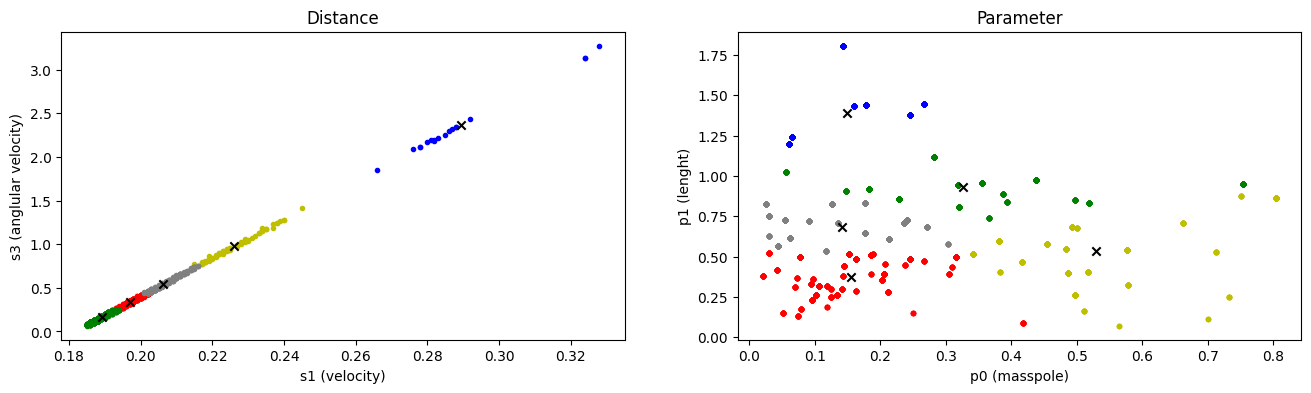

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))
# plot_clusters(axs, df.loc[df['a'] == 0].copy())
plot_clusters(axs[0], cluster_model=kmeans, d=X, cols=['dist_s1', 'dist_s3'], title='Distance', labels=['s1 (velocity)', 's3 (anglular velocity)'])
# plot_clusters(axs[0], cluster_model=kmeans, d=X, cols=['dist_s0', 'dist_s2'], title='Distance', labels=['s0 (position)', 's2 (angle)'])
plot_clusters(axs[1], cluster_model=kmeans_p, d=X_p, cols=['p0', 'p1'], title='Parameter', labels=['p0 (masspole)', 'p1 (lenght)'])

plt.show()

# Train Models

In [9]:
# train_dataset = df[[
#     's0', 's1', 's2', 's3', 'a', 's_0', 's_1', 's_2', 's_3', 'p0', 'p1', 'group'
# ]]
train_dataset = df[[
    's', 's_', 's__', 'a', 'a_', 'r', 'p', 'group'
]]

In [10]:
models = [Base_Line_Simple_Model() for _ in train_dataset.group.unique()]
train_data = [None for _ in models]


for g, model in enumerate(models):
    print('train cluster: ', g)
    group_data = train_dataset.loc[train_dataset['group']==g]
    x, y = model.get_features_targets(group_data)
    trainer = model.train(x, y, num_epochs=10000)
    train_data[g] = data.get_training_data(trainer, inference_schema=model.inference_schema)

train_data[0].head()

train cluster:  0
train cluster:  1
train cluster:  2
train cluster:  3
train cluster:  4


,epoch,mse_s,transition,reward
0,0,"[0.10300548374652863, 0.7360349297523499, 0.02...",1.799351,2.203839
1,1,"[0.10087098181247711, 0.7288535237312317, 0.02...",1.780573,2.191084
2,2,"[0.09877493977546692, 0.7217150330543518, 0.02...",1.762007,2.178484
3,3,"[0.09671787172555923, 0.7146170139312744, 0.02...",1.743654,2.166036
4,4,"[0.0947004184126854, 0.7075561881065369, 0.022...",1.725513,2.153737


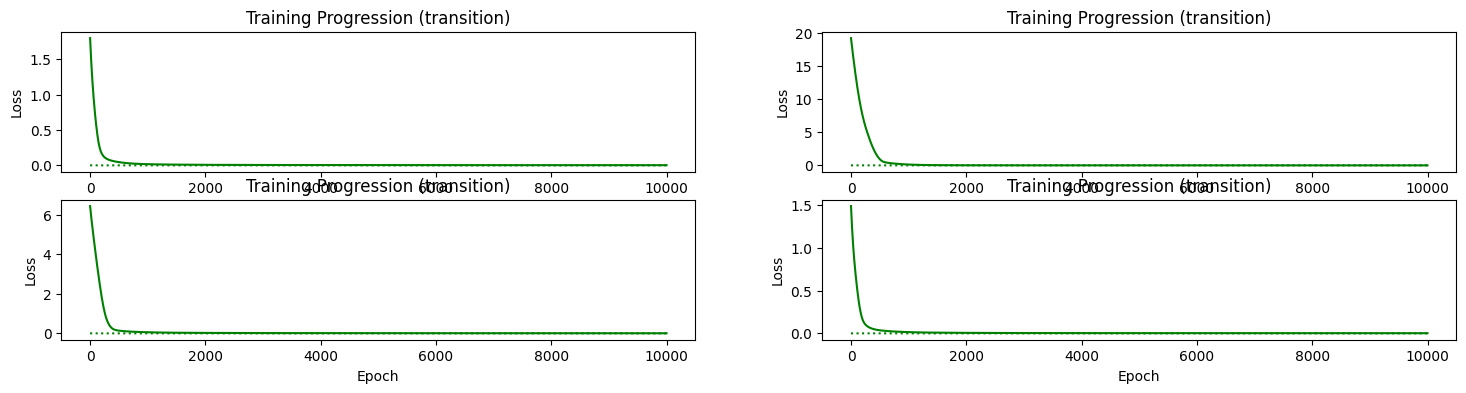

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(18, 4))

data.plot_training_loss(axs[0][0], train_data[0].transition)
data.plot_training_loss(axs[0][1], train_data[1].transition)
data.plot_training_loss(axs[1][0], train_data[2].transition)
data.plot_training_loss(axs[1][1], train_data[3].transition)

plt.show()

# Evaluation

In [12]:
data.evaluate_model(model, path='../testing_data.csv')

expansions = {
    's': ['s0', 's1', 's2', 's3'],
    's_': ['s_0', 's_1', 's_2', 's_3'],
    'p': ['p0', 'p1'],
}

df = get_data_expanded(data.build_training_dataset(), expansions)
df = df.loc[df['episode']<15].copy()
df

,step,episode,p,s,a,r,s_,a_,r_,s__,s0,s1,s2,s3,s_0,s_1,s_2,s_3,p0,p1
112,24,5,"(0.3551867425587211, 0.959194989729514)","(-0.077, -0.735, 0.111, 0.823)",0,1.0,"(-0.091, -0.926, 0.128, 1.031)",0.0,1.0,"(-0.11, -1.117, 0.148, 1.242)",-0.077,-0.735,0.111,0.823,-0.091,-0.926,0.128,1.031,0.355187,0.959195
44,8,2,"(0.1598550005459618, 1.430854105014944)","(-0.079, -0.768, 0.057, 0.423)",1,1.0,"(-0.095, -0.582, 0.066, 0.323)",0.0,1.0,"(-0.106, -0.769, 0.072, 0.437)",-0.079,-0.768,0.057,0.423,-0.095,-0.582,0.066,0.323,0.159855,1.430854
184,68,6,"(0.2451557536988955, 1.3793967951445396)","(-0.228, -0.75, -0.038, 0.134)",1,1.0,"(-0.243, -0.562, -0.036, 0.01)",1.0,1.0,"(-0.254, -0.375, -0.035, -0.113)",-0.228,-0.750,-0.038,0.134,-0.243,-0.562,-0.036,0.010,0.245156,1.379397
364,10,13,"(0.2403247570594251, 0.7298838219922094)","(0.055, 0.799, 0.021, -0.827)",0,1.0,"(0.071, 0.607, 0.004, -0.599)",0.0,1.0,"(0.083, 0.415, -0.008, -0.374)",0.055,0.799,0.021,-0.827,0.071,0.607,0.004,-0.599,0.240325,0.729884
39,3,2,"(0.1598550005459618, 1.430854105014944)","(-0.036, -0.581, 0.036, 0.291)",1,1.0,"(-0.048, -0.394, 0.041, 0.188)",1.0,1.0,"(-0.056, -0.208, 0.045, 0.086)",-0.036,-0.581,0.036,0.291,-0.048,-0.394,0.041,0.188,0.159855,1.430854
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,3,5,"(0.3551867425587211, 0.959194989729514)","(0.044, 0.221, -0.011, -0.209)",0,1.0,"(0.048, 0.031, -0.015, -0.024)",0.0,1.0,"(0.049, -0.159, -0.016, 0.161)",0.044,0.221,-0.011,-0.209,0.048,0.031,-0.015,-0.024,0.355187,0.959195
130,14,6,"(0.2451557536988955, 1.3793967951445396)","(-0.019, 0.359, -0.007, -0.263)",1,1.0,"(-0.012, 0.547, -0.012, -0.383)",0.0,1.0,"(-0.001, 0.359, -0.02, -0.265)",-0.019,0.359,-0.007,-0.263,-0.012,0.547,-0.012,-0.383,0.245156,1.379397
270,22,9,"(0.0614156820293939, 0.6127438843111195)","(-0.001, -0.032, 0.093, 0.269)",0,1.0,"(-0.002, -0.226, 0.099, 0.523)",1.0,1.0,"(-0.006, -0.034, 0.109, 0.317)",-0.001,-0.032,0.093,0.269,-0.002,-0.226,0.099,0.523,0.061416,0.612744
254,6,9,"(0.0614156820293939, 0.6127438843111195)","(0.015, -0.407, 0.038, 0.519)",1,1.0,"(0.007, -0.215, 0.048, 0.297)",1.0,1.0,"(0.003, -0.024, 0.054, 0.077)",0.015,-0.407,0.038,0.519,0.007,-0.215,0.048,0.297,0.061416,0.612744


In [13]:
data = Experiment_Data()

data.load(path='../testing_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
1487,9,75,"(0.0300576953941935, 0.596864957368547)","(-0.05, -0.614, 0.042, 0.772)",1,1.0,"(-0.063, -0.422, 0.058, 0.55)",1.0,1.0,"(-0.071, -0.231, 0.069, 0.331)"
589,4,31,"(0.4456006051678612, 0.2809654390334451)","(0.037, -0.472, 0.018, 1.423)",1,1.0,"(0.027, -0.259, 0.047, 0.74)",1.0,1.0,"(0.022, -0.047, 0.062, 0.079)"
45,14,3,"(0.0248513435450844, 0.7707755296708256)","(-0.129, -0.413, 0.122, 0.513)",0,1.0,"(-0.137, -0.604, 0.132, 0.715)",1.0,1.0,"(-0.15, -0.415, 0.146, 0.562)"
1442,13,73,"(0.1636502017977269, 0.7691648677272466)","(-0.105, -0.212, 0.091, 0.288)",1,1.0,"(-0.109, -0.022, 0.097, 0.109)",1.0,1.0,"(-0.11, 0.167, 0.099, -0.068)"
234,15,15,"(0.0385460830243375, 0.3725217881160826)","(-0.063, -0.179, 0.153, 0.59)",0,1.0,"(-0.067, -0.38, 0.165, 1.023)",0.0,1.0,"(-0.074, -0.581, 0.186, 1.459)"
...,...,...,...,...,...,...,...,...,...,...
598,13,31,"(0.4456006051678612, 0.2809654390334451)","(0.045, -0.267, -0.009, 0.931)",1,1.0,"(0.039, -0.054, 0.009, 0.227)",1.0,1.0,"(0.038, 0.16, 0.014, -0.463)"
1935,16,94,"(0.0254651302537499, 0.563139150076435)","(0.045, 0.805, -0.076, -1.123)",0,1.0,"(0.061, 0.613, -0.098, -0.898)",1.0,1.0,"(0.074, 0.807, -0.116, -1.169)"
1,1,0,"(0.5280280669895349, 0.1691488904272192)","(-0.019, -0.285, 0.013, 1.258)",0,1.0,"(-0.025, -0.525, 0.038, 2.534)",1.0,1.0,"(-0.035, -0.288, 0.088, 1.326)"
201,1,13,"(0.0356460573001723, 0.6790633168873473)","(0.037, -0.156, 0.031, 0.189)",0,1.0,"(0.034, -0.347, 0.034, 0.401)",0.0,1.0,"(0.027, -0.539, 0.042, 0.615)"


In [14]:
expansions = {
    's': ['s0', 's1', 's2', 's3'],
    's_': ['s_0', 's_1', 's_2', 's_3'],
    'p': ['p0', 'p1'],
}

df = get_data_expanded(data.build_training_dataset(), expansions)
df.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,s0,s1,s2,s3,s_0,s_1,s_2,s_3,p0,p1
219,0,15,"(0.0385460830243375, 0.3725217881160826)","(0.019, 0.032, -0.016, -0.046)",0,1.0,"(0.02, -0.167, -0.016, 0.324)",1.0,1.0,"(0.017, 0.032, -0.01, -0.058)",0.019,0.032,-0.016,-0.046,0.020,-0.167,-0.016,0.324,0.038546,0.372522
1115,1,53,"(0.1909291629771446, 0.3016545966525282)","(-0.048, -0.183, -0.016, 0.553)",1,1.0,"(-0.052, 0.023, -0.005, 0.025)",0.0,1.0,"(-0.052, -0.183, -0.004, 0.542)",-0.048,-0.183,-0.016,0.553,-0.052,0.023,-0.005,0.025,0.190929,0.301655
849,25,40,"(0.140012193397569, 0.9881272166912706)","(-0.037, -0.555, 0.111, 0.588)",1,1.0,"(-0.048, -0.367, 0.123, 0.454)",1.0,1.0,"(-0.055, -0.179, 0.132, 0.323)",-0.037,-0.555,0.111,0.588,-0.048,-0.367,0.123,0.454,0.140012,0.988127
4,4,0,"(0.5280280669895349, 0.1691488904272192)","(-0.041, -0.532, 0.115, 2.694)",1,1.0,"(-0.052, -0.3, 0.169, 1.601)",0.0,1.0,"(-0.058, -0.546, 0.201, 3.045)",-0.041,-0.532,0.115,2.694,-0.052,-0.300,0.169,1.601,0.528028,0.169149
57,7,4,"(0.1498943705798889, 0.4424751609431607)","(0.08, 0.59, -0.014, -1.003)",1,1.0,"(0.092, 0.788, -0.034, -1.352)",0.0,1.0,"(0.107, 0.591, -0.061, -1.021)",0.080,0.590,-0.014,-1.003,0.092,0.788,-0.034,-1.352,0.149894,0.442475


In [15]:
df['dist_s0'] = dist('s0', 's_0') 
df['dist_s1'] = dist('s1', 's_1')
df['dist_s2'] = dist('s2', 's_2')
df['dist_s3'] = dist('s3', 's_3')

df.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,...,s_0,s_1,s_2,s_3,p0,p1,dist_s0,dist_s1,dist_s2,dist_s3
219,0,15,"(0.0385460830243375, 0.3725217881160826)","(0.019, 0.032, -0.016, -0.046)",0,1.0,"(0.02, -0.167, -0.016, 0.324)",1.0,1.0,"(0.017, 0.032, -0.01, -0.058)",...,0.020,-0.167,-0.016,0.324,0.038546,0.372522,0.001,0.199,0.000,0.370
1115,1,53,"(0.1909291629771446, 0.3016545966525282)","(-0.048, -0.183, -0.016, 0.553)",1,1.0,"(-0.052, 0.023, -0.005, 0.025)",0.0,1.0,"(-0.052, -0.183, -0.004, 0.542)",...,-0.052,0.023,-0.005,0.025,0.190929,0.301655,0.004,0.206,0.011,0.528
849,25,40,"(0.140012193397569, 0.9881272166912706)","(-0.037, -0.555, 0.111, 0.588)",1,1.0,"(-0.048, -0.367, 0.123, 0.454)",1.0,1.0,"(-0.055, -0.179, 0.132, 0.323)",...,-0.048,-0.367,0.123,0.454,0.140012,0.988127,0.011,0.188,0.012,0.134
4,4,0,"(0.5280280669895349, 0.1691488904272192)","(-0.041, -0.532, 0.115, 2.694)",1,1.0,"(-0.052, -0.3, 0.169, 1.601)",0.0,1.0,"(-0.058, -0.546, 0.201, 3.045)",...,-0.052,-0.300,0.169,1.601,0.528028,0.169149,0.011,0.232,0.054,1.093
57,7,4,"(0.1498943705798889, 0.4424751609431607)","(0.08, 0.59, -0.014, -1.003)",1,1.0,"(0.092, 0.788, -0.034, -1.352)",0.0,1.0,"(0.107, 0.591, -0.061, -1.021)",...,0.092,0.788,-0.034,-1.352,0.149894,0.442475,0.012,0.198,0.020,0.349


In [16]:
X = df[['dist_s1', 'dist_s3']]

groups = kmeans.predict(X)

# for i, label in enumerate(np.unique(kmeans.labels_)):
    # df.loc[kmeans.labels_ == label, 'group'] = i
df['group'] = groups
df.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,...,s_1,s_2,s_3,p0,p1,dist_s0,dist_s1,dist_s2,dist_s3,group
219,0,15,"(0.0385460830243375, 0.3725217881160826)","(0.019, 0.032, -0.016, -0.046)",0,1.0,"(0.02, -0.167, -0.016, 0.324)",1.0,1.0,"(0.017, 0.032, -0.01, -0.058)",...,-0.167,-0.016,0.324,0.038546,0.372522,0.001,0.199,0.000,0.370,0
1115,1,53,"(0.1909291629771446, 0.3016545966525282)","(-0.048, -0.183, -0.016, 0.553)",1,1.0,"(-0.052, 0.023, -0.005, 0.025)",0.0,1.0,"(-0.052, -0.183, -0.004, 0.542)",...,0.023,-0.005,0.025,0.190929,0.301655,0.004,0.206,0.011,0.528,4
849,25,40,"(0.140012193397569, 0.9881272166912706)","(-0.037, -0.555, 0.111, 0.588)",1,1.0,"(-0.048, -0.367, 0.123, 0.454)",1.0,1.0,"(-0.055, -0.179, 0.132, 0.323)",...,-0.367,0.123,0.454,0.140012,0.988127,0.011,0.188,0.012,0.134,3
4,4,0,"(0.5280280669895349, 0.1691488904272192)","(-0.041, -0.532, 0.115, 2.694)",1,1.0,"(-0.052, -0.3, 0.169, 1.601)",0.0,1.0,"(-0.058, -0.546, 0.201, 3.045)",...,-0.300,0.169,1.601,0.528028,0.169149,0.011,0.232,0.054,1.093,2
57,7,4,"(0.1498943705798889, 0.4424751609431607)","(0.08, 0.59, -0.014, -1.003)",1,1.0,"(0.092, 0.788, -0.034, -1.352)",0.0,1.0,"(0.107, 0.591, -0.061, -1.021)",...,0.788,-0.034,-1.352,0.149894,0.442475,0.012,0.198,0.020,0.349,0


In [17]:
evaluation_dataset = df[[
    's', 's_', 's__', 'a', 'a_', 'r', 'p', 'group'
]]

In [18]:
expanded_data = get_data_expanded(evaluation_dataset, {
                's': ['s0', 's1', 's2', 's3'],
                's_': ['s_0', 's_1', 's_2', 's_3'],
                's__': ['s__0', 's__1', 's__2', 's__3'],
                'p': ['p0', 'p1']
        })

In [19]:
evaluation_dataset[models[0].grouped_targets_lables] = expanded_data.apply(lambda row: data._predict_from_row(row, models[row.group]), axis=1, result_type='expand')
evaluation_dataset.head()

/tmp/ipykernel_10256/530237357.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  evaluation_dataset[models[0].grouped_targets_lables] = expanded_data.apply(lambda row: data._predict_from_row(row, models[row.group]), axis=1, result_type='expand')
/tmp/ipykernel_10256/530237357.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  evaluation_dataset[models[0].grouped_targets_lables] = expanded_data.apply(lambda row: data._predict_from_row(row, models[row.group]), axis=1, result_type='expand')


,s,s_,s__,a,a_,r,p,group,estimated_s,estimated_r
219,"(0.019, 0.032, -0.016, -0.046)","(0.02, -0.167, -0.016, 0.324)","(0.017, 0.032, -0.01, -0.058)",0,1.0,1.0,"(0.0385460830243375, 0.3725217881160826)",0,"(0.016, 0.032, -0.01, -0.024)",1.0
1115,"(-0.048, -0.183, -0.016, 0.553)","(-0.052, 0.023, -0.005, 0.025)","(-0.052, -0.183, -0.004, 0.542)",1,0.0,1.0,"(0.1909291629771446, 0.3016545966525282)",4,"(-0.054, -0.183, -0.006, 0.612)",1.0
849,"(-0.037, -0.555, 0.111, 0.588)","(-0.048, -0.367, 0.123, 0.454)","(-0.055, -0.179, 0.132, 0.323)",1,1.0,1.0,"(0.140012193397569, 0.9881272166912706)",3,"(-0.052, -0.177, 0.133, 0.317)",1.0
4,"(-0.041, -0.532, 0.115, 2.694)","(-0.052, -0.3, 0.169, 1.601)","(-0.058, -0.546, 0.201, 3.045)",1,0.0,1.0,"(0.5280280669895349, 0.1691488904272192)",2,"(-0.057, -0.517, 0.194, 2.398)",1.0
57,"(0.08, 0.59, -0.014, -1.003)","(0.092, 0.788, -0.034, -1.352)","(0.107, 0.591, -0.061, -1.021)",1,0.0,1.0,"(0.1498943705798889, 0.4424751609431607)",0,"(0.113, 0.583, -0.062, -0.963)",1.0


In [20]:
results = data.get_evaluation_metrics(evaluation_dataset, p=False)
results.head()

,s,s_,s__,a,a_,r,p,group,estimated_s,estimated_r,...,rse_s1,rse_s2,rse_s3,rse_r,rse_s0_normalized,rse_s1_normalized,rse_s2_normalized,rse_s3_normalized,rse,rse_normalized
219,"(0.019, 0.032, -0.016, -0.046)","(0.02, -0.167, -0.016, 0.324)","(0.017, 0.032, -0.01, -0.058)",0,1.0,1.0,"(0.0385460830243375, 0.3725217881160826)",0,"(0.016, 0.032, -0.01, -0.024)",1.0,...,0.000,0.000,0.034,0.0,0.546990,0.526057,0.501199,0.437580,0.035,0.502957
1115,"(-0.048, -0.183, -0.016, 0.553)","(-0.052, 0.023, -0.005, 0.025)","(-0.052, -0.183, -0.004, 0.542)",1,0.0,1.0,"(0.1909291629771446, 0.3016545966525282)",4,"(-0.054, -0.183, -0.006, 0.612)",1.0,...,0.000,0.002,0.070,0.0,0.548046,0.526057,0.505995,0.440661,0.074,0.505190
849,"(-0.037, -0.555, 0.111, 0.588)","(-0.048, -0.367, 0.123, 0.454)","(-0.055, -0.179, 0.132, 0.323)",1,1.0,1.0,"(0.140012193397569, 0.9881272166912706)",3,"(-0.052, -0.177, 0.133, 0.317)",1.0,...,0.002,0.001,0.006,0.0,0.549102,0.526549,0.503597,0.435184,0.012,0.503608
4,"(-0.041, -0.532, 0.115, 2.694)","(-0.052, -0.3, 0.169, 1.601)","(-0.058, -0.546, 0.201, 3.045)",1,0.0,1.0,"(0.5280280669895349, 0.1691488904272192)",2,"(-0.057, -0.517, 0.194, 2.398)",1.0,...,0.029,0.007,0.647,0.0,0.546990,0.533186,0.517986,0.490032,0.684,0.522048
57,"(0.08, 0.59, -0.014, -1.003)","(0.092, 0.788, -0.034, -1.352)","(0.107, 0.591, -0.061, -1.021)",1,0.0,1.0,"(0.1498943705798889, 0.4424751609431607)",0,"(0.113, 0.583, -0.062, -0.963)",1.0,...,0.008,0.001,0.058,0.0,0.552270,0.528024,0.503597,0.439634,0.073,0.505881


In [21]:
results[['rse', 'rse_normalized', 
         'rse_s0', 'rse_s0_normalized',
         'rse_s1', 'rse_s1_normalized', 
         'rse_s2', 'rse_s2_normalized',
         'rse_s3', 'rse_s3_normalized']].describe()

,rse,rse_normalized,rse_s0,rse_s0_normalized,rse_s1,rse_s1_normalized,rse_s2,rse_s2_normalized,rse_s3,rse_s3_normalized
count,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000
mean,0.071566,0.505482,0.002918,0.549016,0.005932,0.527515,0.001799,0.505514,0.060917,0.439883
std,0.082947,0.003935,0.003864,0.004080,0.009213,0.002265,0.003372,0.008085,0.075426,0.006454
min,0.001000,0.502008,0.000000,0.545935,0.000000,0.526057,0.000000,0.501199,0.000000,0.434671
25%,0.026500,0.503645,0.001000,0.546990,0.002000,0.526549,0.000000,0.501199,0.019000,0.436297
50%,0.054000,0.504514,0.002000,0.548046,0.003000,0.526794,0.001000,0.503597,0.045000,0.438521
75%,0.083000,0.505911,0.004000,0.550158,0.006000,0.527532,0.002000,0.505995,0.073000,0.440917
max,1.475000,0.558947,0.049000,0.597677,0.129000,0.557768,0.057000,0.637890,1.332000,0.548644


In [22]:
results[['group', 'rse', 'rse_normalized', 
         'rse_s0', 'rse_s0_normalized',
         'rse_s1', 'rse_s1_normalized', 
         'rse_s2', 'rse_s2_normalized',
         'rse_s3', 'rse_s3_normalized']].groupby('group').mean()

,rse,rse_normalized,rse_s0,rse_s0_normalized,rse_s1,rse_s1_normalized,rse_s2,rse_s2_normalized,rse_s3,rse_s3_normalized
group,,,,,,,,,,
0,0.057174,0.505170,0.003376,0.549500,0.005895,0.527506,0.001603,0.505042,0.046300,0.438633
1,0.360714,0.532529,0.023643,0.570901,0.044714,0.537049,0.026500,0.564748,0.265857,0.457419
2,0.215815,0.510913,0.003311,0.549431,0.018454,0.530593,0.004824,0.512766,0.189227,0.450862
3,0.048269,0.504323,0.002286,0.548349,0.004034,0.527049,0.001054,0.503726,0.040895,0.438170
4,0.107335,0.506602,0.003027,0.549131,0.005832,0.527491,0.002374,0.506893,0.096102,0.442894
